# Symbolic Knowledge Discovery - XWine Dataset

This notebook follows the workflow style from:
- `resources/FCA_From_Scratch_SymbolicKD.ipynb`
- `resources/SymbolicKD_Pattern_Mining_+_Clustering.ipynb`

The run is intentionally lightweight to avoid computationally heavy processing:
- full binary-context mining with `caspailleur`
- sampled pattern-space mining with `paspailleur` for subgroup exploration


In [1]:
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

OUTPUT_DIR = Path("outputs/xwine_symbolic_kd_light")
summary = json.loads((OUTPUT_DIR / "summary.json").read_text(encoding="utf-8"))
summary


{'dataset': 'xwine',
 'n_objects': 100,
 'n_binary_features': 77,
 'caspailleur_concepts': 3527,
 'caspailleur_implications': 1704,
 'pattern_structure_shape': [10, 35],
 'subgroup_files': {'high_abv_quartile': 'subgroups_high_abv_quartile.csv'},
 'subgroup_rationale': {'high_abv_quartile': 'ABV top quartile (>= 14.15) isolates stronger wine profiles.'},
 'year_grouping_justification': 'Year-based subgrouping uses broader eras (<=2010 vs >2010) instead of consecutive pairs to reduce sparsity and improve interpretability.'}

## 1) Context and Dataset Overview

We mine a binary context for FCA (caspailleur) and a compact multi-dimensional pattern structure for subgroup-oriented exploration (paspailleur).


In [2]:
context = pd.read_csv(OUTPUT_DIR / "binary_context.csv")
concepts = pd.read_csv(OUTPUT_DIR / "caspailleur_concepts.csv")
implications = pd.read_csv(OUTPUT_DIR / "caspailleur_implications.csv")
feature_importance = pd.read_csv(OUTPUT_DIR / "feature_importance.csv")
interesting_implications = pd.read_csv(OUTPUT_DIR / "interesting_implications.csv")
paspailleur_concepts = pd.read_csv(OUTPUT_DIR / "paspailleur_concepts.csv")

print("Context shape:", context.shape)
print("Caspailleur concepts:", len(concepts))
print("Caspailleur implications:", len(implications))
print("Paspailleur concepts (sampled pattern structure):", len(paspailleur_concepts))


Context shape: (100, 78)
Caspailleur concepts: 3527
Caspailleur implications: 1704
Paspailleur concepts (sampled pattern structure): 152


## 2) Feature Importance (more important vs less important)

Importance combines:
- binary support (frequency)
- stability-weighted concept participation
- implication participation weight


,feature,support_ratio,concept_weight,implication_weight,importance_score
0,avg_harvest_start_to_2007_missing,0.99,686.47,8.504,695.964
1,region_clean_Other,0.79,360.73,28.776,390.296
2,Type_Red,0.53,231.54,30.812,262.882
3,food::Beef,0.53,196.75,30.220,227.500
4,Elaborate_Varietal/100%,0.58,164.19,29.896,194.666
5,latest_vintage_low,0.53,131.69,22.020,154.240
6,Acidity_Medium,0.54,129.79,20.152,150.482
7,Body_Medium-bodied,0.46,95.19,18.876,114.526
8,abv_num_low,0.49,90.04,20.608,111.138
9,food::Poultry,0.38,75.55,21.412,97.342


,feature,support_ratio,concept_weight,implication_weight,importance_score
62,Country_Chile,0.04,0.0,0.048,0.088
63,region_clean_Vinho Verde,0.03,0.0,0.000,0.030
64,region_clean_Willamette Valley,0.03,0.0,0.000,0.030
65,region_clean_Langhe,0.03,0.0,0.000,0.030
66,region_clean_Porto,0.03,0.0,0.000,0.030
67,Country_Germany,0.03,0.0,0.000,0.030
68,region_clean_Barolo,0.03,0.0,0.000,0.030
69,Elaborate_Other,0.02,0.0,0.000,0.020
70,Elaborate_Assemblage/Valpolicella Red Blend,0.02,0.0,0.000,0.020
71,Elaborate_Assemblage/Provence Rosé Blend,0.02,0.0,0.000,0.020


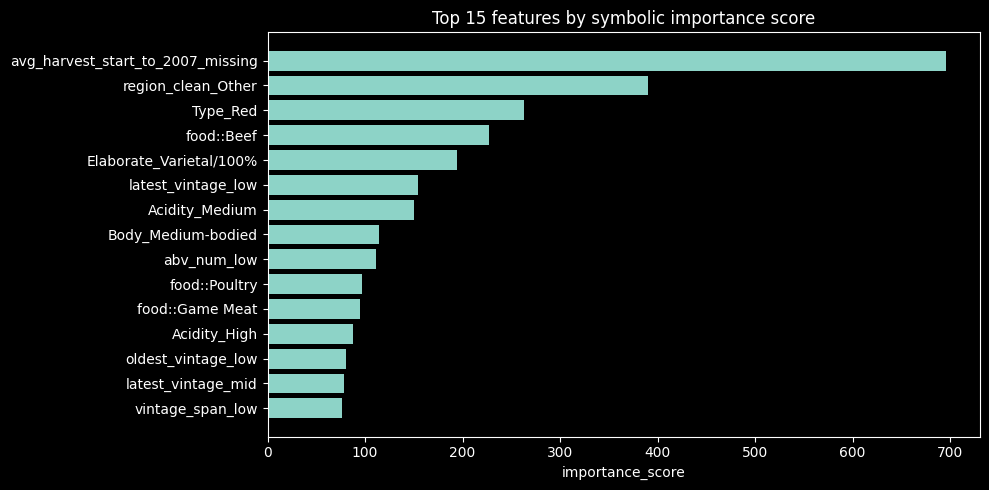

In [3]:
top_features = feature_importance.head(15).copy()
low_features = feature_importance.tail(15).copy()

display(top_features)
display(low_features)

plt.figure(figsize=(10, 5))
plt.barh(top_features["feature"][::-1], top_features["importance_score"][::-1])
plt.title("Top 15 features by symbolic importance score")
plt.xlabel("importance_score")
plt.tight_layout()
plt.show()


## 3) Concepts (including cool/stable concepts)

`caspailleur` returns concept intents/extents with support and delta stability.
We inspect high-support and high-stability concepts.


In [4]:
stable_concepts = concepts.sort_values(["delta_stability", "support"], ascending=[False, False]).head(20)
support_concepts = concepts.sort_values("support", ascending=False).head(20)

display(stable_concepts)
display(support_concepts)


,extent,intent,support,delta_stability
0,"{'xwine_0036', 'xwine_0001', 'xwine_0071', 'xw...","{'region_clean_Other', 'avg_harvest_start_to_2...",78,30
1,"{'xwine_0036', 'xwine_0001', 'xwine_0071', 'xw...",{'avg_harvest_start_to_2007_missing'},99,21
2,"{'xwine_0037', 'xwine_0017', 'xwine_0001', 'xw...","{'Elaborate_Varietal/100%', 'region_clean_Othe...",48,19
3,"{'xwine_0037', 'xwine_0036', 'xwine_0001', 'xw...","{'region_clean_Other', 'avg_harvest_start_to_2...",43,15
4,"{'xwine_0017', 'xwine_0001', 'xwine_0050', 'xw...","{'abv_num_low', 'region_clean_Other', 'avg_har...",40,14
5,"{'xwine_0037', 'xwine_0014', 'xwine_0036', 'xw...","{'avg_harvest_start_to_2007_missing', 'latest_...",52,13
6,"{'xwine_0001', 'xwine_0078', 'xwine_0071', 'xw...","{'region_clean_Other', 'avg_harvest_start_to_2...",34,13
8,"{'xwine_0036', 'xwine_0017', 'xwine_0078', 'xw...","{'food::Beef', 'region_clean_Other', 'avg_harv...",40,12
7,"{'xwine_0037', 'xwine_0036', 'xwine_0017', 'xw...","{'avg_harvest_start_to_2007_missing', 'region_...",39,12
9,"{'xwine_0017', 'xwine_0071', 'xwine_0063', 'xw...","{'region_clean_Other', 'avg_harvest_start_to_2...",35,11


,extent,intent,support,delta_stability
1047,"{'xwine_0036', 'xwine_0001', 'xwine_0071', 'xw...",set(),100,1
1,"{'xwine_0036', 'xwine_0001', 'xwine_0071', 'xw...",{'avg_harvest_start_to_2007_missing'},99,21
1050,"{'xwine_0036', 'xwine_0001', 'xwine_0071', 'xw...",{'region_clean_Other'},79,1
0,"{'xwine_0036', 'xwine_0001', 'xwine_0071', 'xw...","{'region_clean_Other', 'avg_harvest_start_to_2...",78,30
1049,"{'xwine_0037', 'xwine_0034', 'xwine_0041', 'xw...",{'Elaborate_Varietal/100%'},58,1
17,"{'xwine_0037', 'xwine_0041', 'xwine_0017', 'xw...","{'Elaborate_Varietal/100%', 'avg_harvest_start...",57,9
1052,"{'xwine_0037', 'xwine_0034', 'xwine_0014', 'xw...",{'Acidity_Medium'},54,1
13,"{'xwine_0037', 'xwine_0014', 'xwine_0036', 'xw...","{'avg_harvest_start_to_2007_missing', 'Acidity...",53,10
113,"{'xwine_0036', 'xwine_0041', 'xwine_0017', 'xw...","{'avg_harvest_start_to_2007_missing', 'Type_Red'}",53,4
115,"{'xwine_0036', 'xwine_0041', 'xwine_0017', 'xw...","{'food::Beef', 'avg_harvest_start_to_2007_miss...",53,4


## 4) Implications (highlight interesting ones)

The table below shows a compact ranked set of implications to discuss (3-5 most interesting).


,premise,conclusion,support,delta_stability,premise_len,conclusion_len,interesting_score
0,{'food::Beef'},{'avg_harvest_start_to_2007_missing'},53,4,1,1,71.55
1,{'Type_Red'},{'avg_harvest_start_to_2007_missing'},53,4,1,1,71.55
2,{'abv_num_low'},{'avg_harvest_start_to_2007_missing'},49,9,1,1,66.15
3,{'Acidity_High'},{'avg_harvest_start_to_2007_missing'},45,10,1,1,60.75
4,{'food::Game Meat'},"{'avg_harvest_start_to_2007_missing', 'Type_Red'}",39,2,1,2,58.50


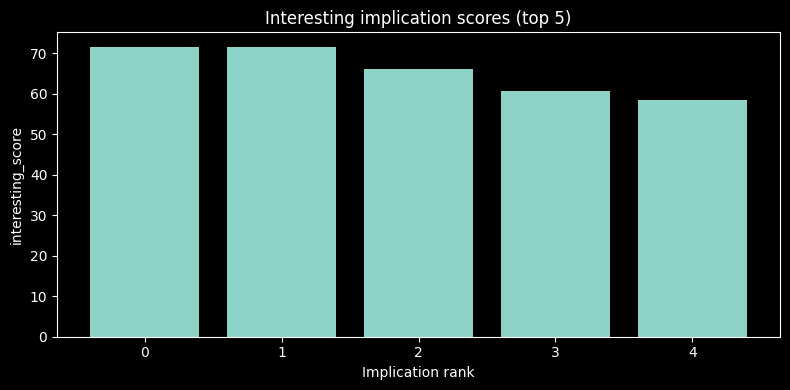

In [5]:
display(interesting_implications.head(5))

if len(interesting_implications) > 0:
    plt.figure(figsize=(8, 4))
    plt.bar(range(len(interesting_implications.head(5))), interesting_implications.head(5)["interesting_score"])
    plt.title("Interesting implication scores (top 5)")
    plt.xlabel("Implication rank")
    plt.ylabel("interesting_score")
    plt.tight_layout()
    plt.show()


## 5) Subgroups (binary targets + rationale)

Subgroups are mined as patterns that are highly precise for a **binary target**.

Detected subgroup files: `subgroups_high_abv_quartile.csv`.

Rationale used in this run:
- `high_abv_quartile`: ABV top quartile (>= 14.15) isolates stronger wine profiles.

Temporal-grouping policy:
- Prefer broad eras (e.g. <=2010 vs >2010) rather than tiny year-pairs (2001-2002, 2002-2003, ...)
- Reason: broader bins reduce sparsity and improve subgroup interpretability/stability


In [6]:
for csv_file in sorted(OUTPUT_DIR.glob("subgroups_*.csv")):
    print("\n===", csv_file.name, "===")
    df = pd.read_csv(csv_file)
    display(df.head(15))



=== subgroups_high_abv_quartile.csv ===


,description,quality,tp,fp,support
0,{'ABV': >= 4.0},0.3,3,7,10
1,{'ABV': >= 12.5},0.3,3,7,10
2,{'ABV': <= 48.0},0.3,3,7,10
3,{'ABV': >= 13.0},0.3,3,7,10
4,{'LatestVintage': >= 2017.0},0.3,3,7,10
5,{'LatestVintage': <= 2022.0},0.3,3,7,10
6,{'LatestVintage': >= 2020.0},0.3,3,7,10
7,{'Body': NOT({'Very light-bodied'})},0.3,3,7,10


## 6) Paspailleur Pattern Concepts (sampled run)

This section mirrors the pattern-mining spirit from the resource notebook but under lightweight constraints.


In [7]:
display(paspailleur_concepts.head(20))


,intent,support,delta_stability
0,"{'ABV': [13.0, 48.0], 'Body': NOT({'Very light...",10,NaN
1,"{'ABV': [13.0, 48.0], 'Body': NOT({'Very light...",9,NaN
2,"{'ABV': [13.0, 48.0], 'Body': NOT({'Very light...",9,NaN
3,"{'ABV': [13.0, 14.5], 'Body': NOT({'Very light...",9,NaN
4,"{'ABV': [13.0, 48.0], 'Body': NOT({'Very light...",9,NaN
5,"{'ABV': [13.0, 48.0], 'Body': NOT({'Very light...",8,NaN
6,"{'ABV': [13.0, 48.0], 'Body': NOT({'Very light...",8,NaN
7,"{'ABV': [13.0, 48.0], 'Body': NOT({'Very light...",8,NaN
8,"{'ABV': [13.0, 14.5], 'Body': NOT({'Very light...",8,NaN
9,"{'ABV': [13.0, 14.5], 'Body': NOT({'Very light...",8,NaN


## 7) Practical Interpretation Notes

- Use top symbolic features as candidate explanatory variables for recommendation/ranking models.
- Validate highlighted implications with domain experts (oenologists/sommeliers).
- Subgroups should be re-mined on larger compute budgets if exhaustive subgroup quality optimization is required.
